LIBRARY IMPORT

In [2]:
import mne
import os

PATH DEFINE

In [3]:
file = "D:/DSP_Thesis_Project/data/chb01_01.edf"
print(file)

D:/DSP_Thesis_Project/data/chb01_01.edf


FILE EXIST CHECK

In [4]:
print(os.path.exists(file))

True


FILE LOAD

In [5]:
raw = mne.io.read_raw_edf(file, preload=True)

print(raw)

Extracting EDF parameters from D:/DSP_Thesis_Project/data/chb01_01.edf...
Setting channel info structure...
Creating raw.info structure...


C:\Users\fahad\AppData\Local\Temp\ipykernel_12772\1045913734.py:1: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file, preload=True)


Reading 0 ... 921599  =      0.000 ...  3599.996 secs...
<RawEDF | chb01_01.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>


BASIC INFO

In [6]:
print("Sampling rate:", raw.info['sfreq'])
print("Channels:", len(raw.ch_names))

Sampling rate: 256.0
Channels: 23


SIGNAL DATA SHAPE

In [7]:
data = raw.get_data()

print("Shape:", data.shape)

Shape: (23, 921600)


QUICK VISUALIZATION

Using matplotlib as 2D backend.


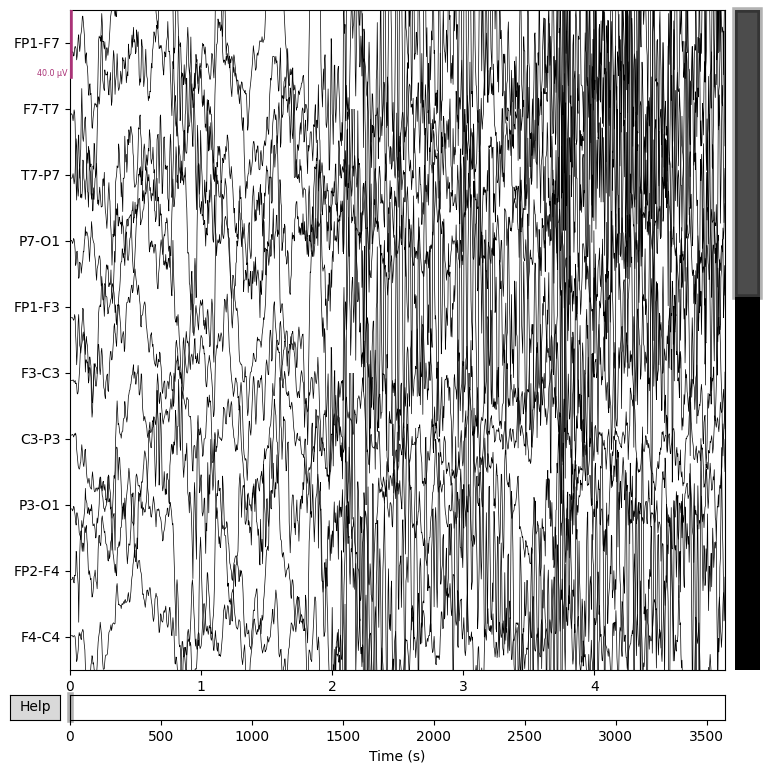

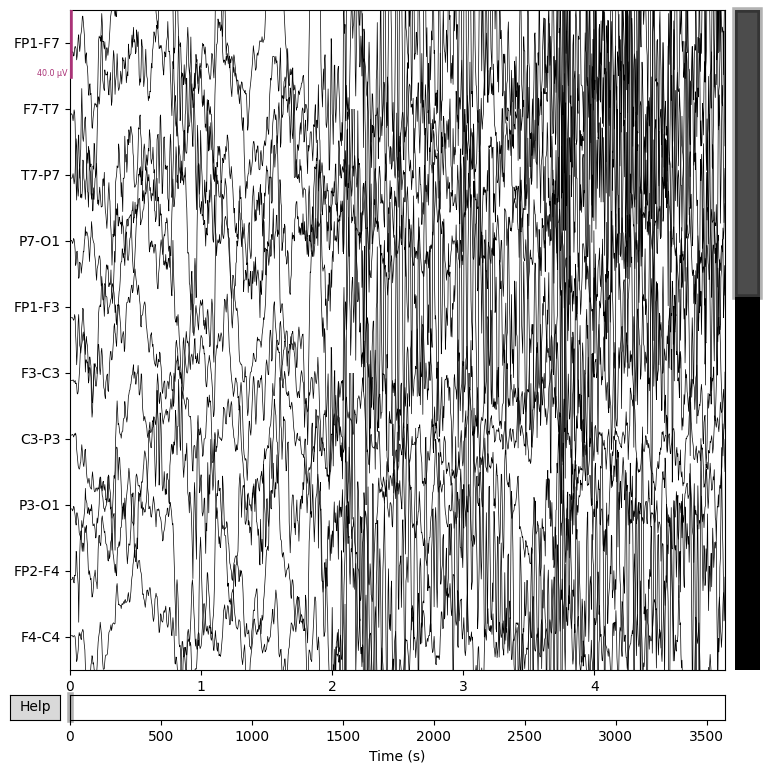

In [8]:
raw.plot(duration=5, n_channels=10)

BANDPASS FILTER

In [9]:
filtered = raw.copy().filter(l_freq=0.5, h_freq=40)

print("Filtering done")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering done


FILTERED GRAPH

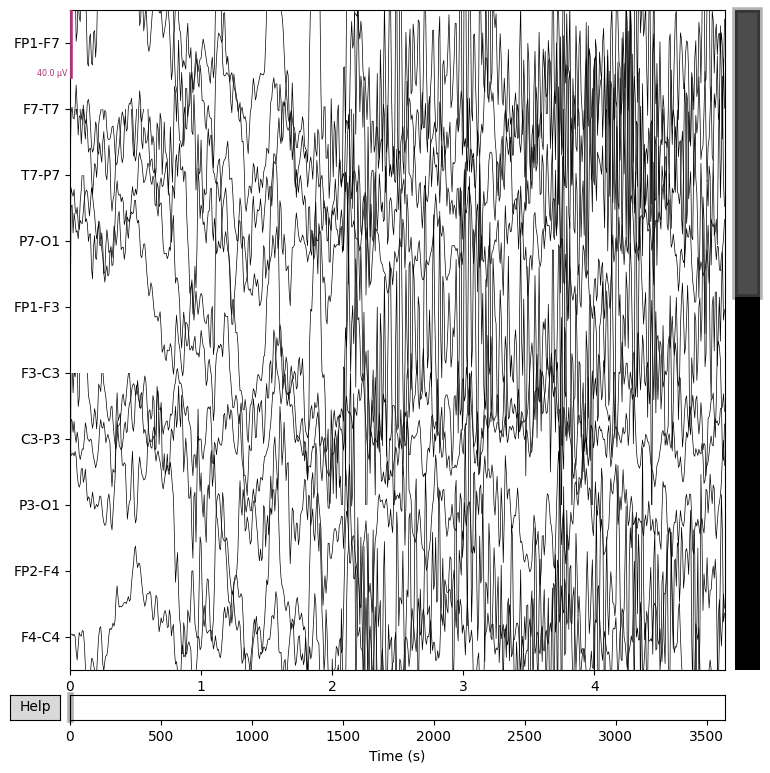

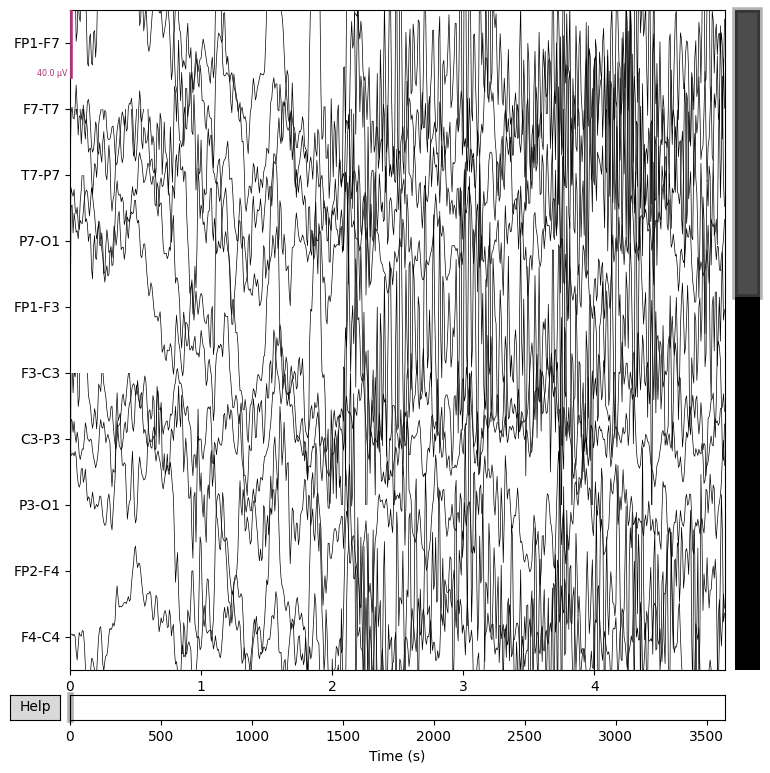

In [10]:
filtered.plot(duration=5, n_channels=10)

SEGMENTATION

In [11]:
import numpy as np

data = filtered.get_data()

fs = int(filtered.info['sfreq'])   # sampling rate

segment_length = fs * 5   # 5 seconds

segments = []

for i in range(0, data.shape[1] - segment_length, segment_length):
    seg = data[:, i:i+segment_length]
    segments.append(seg)

print("Total segments:", len(segments))

Total segments: 719


FEATURE EXTRACTION (EEG)

In [12]:
features_list = []

for seg in segments:
    mean = np.mean(seg, axis=1)
    std = np.std(seg, axis=1)
    energy = np.sum(seg**2)
    
    features = np.hstack([mean, std, energy])
    features_list.append(features)

features_array = np.array(features_list)

print("Feature shape:", features_array.shape)

Feature shape: (719, 47)


    mechine leaning
    STEP 1: LABELS (ABHI DEMO BANATE HAIN)
    Real EEG mein labels file se aate hain, lekin abhi pipeline verify karte hain:

In [13]:
import numpy as np

# demo labels (alternate 0/1)
y = np.array([i % 2 for i in range(len(features_array))])

print("X shape:", features_array.shape)
print("y shape:", y.shape)

X shape: (719, 47)
y shape: (719,)


STEP 2: TRAIN / TEST SPLIT (STRATIFIED)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_array, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# sanity check
print("Train:", np.bincount(y_train))
print("Test :", np.bincount(y_test))

Train: [252 251]
Test : [108 108]


STEP 3: MODEL TRAIN

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print("Model trained ✔")

Model trained ✔


STEP 4: EVALUATION

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pred = model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

Test Accuracy: 0.49074074074074076
              precision    recall  f1-score   support

           0       0.49      0.56      0.53       108
           1       0.49      0.42      0.45       108

    accuracy                           0.49       216
   macro avg       0.49      0.49      0.49       216
weighted avg       0.49      0.49      0.49       216

Confusion Matrix:
 [[61 47]
 [63 45]]


folder create 

In [17]:
import os

os.makedirs("models", exist_ok=True)

STEP 5: MODEL SAVE (DEPLOYMENT READY)

In [18]:
import joblib

joblib.dump(model, "models/eeg_model.pkl")

print("Model saved ✔")

Model saved ✔


STEP 1: MODEL LOAD
NEW EEG FILE PAR PREDICTION (REAL USE CASE)

In [19]:
import joblib

model = joblib.load("models/eeg_model.pkl")
print("Model loaded ✔")

Model loaded ✔


STEP 2: NEW EEG FILE LOAD

In [20]:
import mne

file = "D:/DSP_Thesis_Project/data/chb01_01.edf"   # new ya same test file

raw = mne.io.read_raw_edf(file, preload=True)

Extracting EDF parameters from D:/DSP_Thesis_Project/data/chb01_01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


C:\Users\fahad\AppData\Local\Temp\ipykernel_12772\4183221318.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file, preload=True)


STEP 3: SAME PREPROCESSING (VERY IMPORTANT)
jo training mein kiya tha EXACT same karna hai

In [21]:
filtered = raw.copy().filter(l_freq=0.5, h_freq=40)

data = filtered.get_data()
fs = int(filtered.info['sfreq'])

segment_length = fs * 5

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)



STEP 4: FEATURE EXTRACTION (SAME LOGIC)

In [22]:
import numpy as np

predictions = []

for i in range(0, data.shape[1] - segment_length, segment_length):
    seg = data[:, i:i+segment_length]
    
    mean = np.mean(seg, axis=1)
    std = np.std(seg, axis=1)
    energy = np.sum(seg**2)
    
    features = np.hstack([mean, std, energy])
    features = features.reshape(1, -1)
    
    pred = model.predict(features)
    predictions.append(pred[0])

print(predictions)

[np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0)

STEP 5: FINAL DECISION

In [23]:
if sum(predictions) > len(predictions) / 2:
    print("Abnormal EEG ⚠")
else:
    print("Normal EEG ✔")

Normal EEG ✔


check summery file


In [24]:
import os

print(os.listdir("D:/DSP_Thesis_Project/data"))

['chb01-summary.txt', 'chb01_01.edf', 'chb01_03.edf', 'chb01_03.edf.seizures']


SUMMARY FILE READ

In [25]:
summary_path = "D:/DSP_Thesis_Project/data/chb01-summary.txt"

with open(summary_path, "r") as f:
    text = f.read()

print(text[:3000])

Data Sampling Rate: 256 Hz
*************************

Channels in EDF Files:
**********************
Channel 1: FP1-F7
Channel 2: F7-T7
Channel 3: T7-P7
Channel 4: P7-O1
Channel 5: FP1-F3
Channel 6: F3-C3
Channel 7: C3-P3
Channel 8: P3-O1
Channel 9: FP2-F4
Channel 10: F4-C4
Channel 11: C4-P4
Channel 12: P4-O2
Channel 13: FP2-F8
Channel 14: F8-T8
Channel 15: T8-P8
Channel 16: P8-O2
Channel 17: FZ-CZ
Channel 18: CZ-PZ
Channel 19: P7-T7
Channel 20: T7-FT9
Channel 21: FT9-FT10
Channel 22: FT10-T8
Channel 23: T8-P8

File Name: chb01_01.edf
File Start Time: 11:42:54
File End Time: 12:42:54
Number of Seizures in File: 0

File Name: chb01_02.edf
File Start Time: 12:42:57
File End Time: 13:42:57
Number of Seizures in File: 0

File Name: chb01_03.edf
File Start Time: 13:43:04
File End Time: 14:43:04
Number of Seizures in File: 1
Seizure Start Time: 2996 seconds
Seizure End Time: 3036 seconds

File Name: chb01_04.edf
File Start Time: 14:43:12
File End Time: 15:43:12
Number of Seizures in File: 1
S

summery check


In [26]:
summary_path = "D:/DSP_Thesis_Project/data/chb01-summary.txt"

with open(summary_path, "r") as f:
    text = f.read()

print(text[:3000])

Data Sampling Rate: 256 Hz
*************************

Channels in EDF Files:
**********************
Channel 1: FP1-F7
Channel 2: F7-T7
Channel 3: T7-P7
Channel 4: P7-O1
Channel 5: FP1-F3
Channel 6: F3-C3
Channel 7: C3-P3
Channel 8: P3-O1
Channel 9: FP2-F4
Channel 10: F4-C4
Channel 11: C4-P4
Channel 12: P4-O2
Channel 13: FP2-F8
Channel 14: F8-T8
Channel 15: T8-P8
Channel 16: P8-O2
Channel 17: FZ-CZ
Channel 18: CZ-PZ
Channel 19: P7-T7
Channel 20: T7-FT9
Channel 21: FT9-FT10
Channel 22: FT10-T8
Channel 23: T8-P8

File Name: chb01_01.edf
File Start Time: 11:42:54
File End Time: 12:42:54
Number of Seizures in File: 0

File Name: chb01_02.edf
File Start Time: 12:42:57
File End Time: 13:42:57
Number of Seizures in File: 0

File Name: chb01_03.edf
File Start Time: 13:43:04
File End Time: 14:43:04
Number of Seizures in File: 1
Seizure Start Time: 2996 seconds
Seizure End Time: 3036 seconds

File Name: chb01_04.edf
File Start Time: 14:43:12
File End Time: 15:43:12
Number of Seizures in File: 1
S

ONLY SEIZURE INFO

In [27]:
for line in text.splitlines():

    if "File Name" in line or "Seizure" in line:
        print(line)

File Name: chb01_01.edf
Number of Seizures in File: 0
File Name: chb01_02.edf
Number of Seizures in File: 0
File Name: chb01_03.edf
Number of Seizures in File: 1
Seizure Start Time: 2996 seconds
Seizure End Time: 3036 seconds
File Name: chb01_04.edf
Number of Seizures in File: 1
Seizure Start Time: 1467 seconds
Seizure End Time: 1494 seconds
File Name: chb01_05.edf
Number of Seizures in File: 0
File Name: chb01_06.edf
Number of Seizures in File: 0
File Name: chb01_07.edf
Number of Seizures in File: 0
File Name: chb01_08.edf
Number of Seizures in File: 0
File Name: chb01_09.edf
Number of Seizures in File: 0
File Name: chb01_10.edf
Number of Seizures in File: 0
File Name: chb01_11.edf
Number of Seizures in File: 0
File Name: chb01_12.edf
Number of Seizures in File: 0
File Name: chb01_13.edf
Number of Seizures in File: 0
File Name: chb01_14.edf
Number of Seizures in File: 0
File Name: chb01_15.edf
Number of Seizures in File: 1
Seizure Start Time: 1732 seconds
Seizure End Time: 1772 second

In [28]:
for line in text.splitlines():

    if "File Name" in line or "Seizure" in line:
        print(line)

File Name: chb01_01.edf
Number of Seizures in File: 0
File Name: chb01_02.edf
Number of Seizures in File: 0
File Name: chb01_03.edf
Number of Seizures in File: 1
Seizure Start Time: 2996 seconds
Seizure End Time: 3036 seconds
File Name: chb01_04.edf
Number of Seizures in File: 1
Seizure Start Time: 1467 seconds
Seizure End Time: 1494 seconds
File Name: chb01_05.edf
Number of Seizures in File: 0
File Name: chb01_06.edf
Number of Seizures in File: 0
File Name: chb01_07.edf
Number of Seizures in File: 0
File Name: chb01_08.edf
Number of Seizures in File: 0
File Name: chb01_09.edf
Number of Seizures in File: 0
File Name: chb01_10.edf
Number of Seizures in File: 0
File Name: chb01_11.edf
Number of Seizures in File: 0
File Name: chb01_12.edf
Number of Seizures in File: 0
File Name: chb01_13.edf
Number of Seizures in File: 0
File Name: chb01_14.edf
Number of Seizures in File: 0
File Name: chb01_15.edf
Number of Seizures in File: 1
Seizure Start Time: 1732 seconds
Seizure End Time: 1772 second

SEIZURE FILE LOAD

In [29]:
import mne

file = "D:/DSP_Thesis_Project/data/chb01_03.edf"

raw = mne.io.read_raw_edf(file, preload=True)

print(raw)

Extracting EDF parameters from D:/DSP_Thesis_Project/data/chb01_03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


C:\Users\fahad\AppData\Local\Temp\ipykernel_12772\3093464881.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file, preload=True)


<RawEDF | chb01_03.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>


STEP 2 — FILTERING

In [30]:
filtered = raw.copy().filter(l_freq=0.5, h_freq=40)

print("Filtering done ✔")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering done ✔


DATA + SAMPLING RATE

In [31]:
data = filtered.get_data()

fs = int(filtered.info['sfreq'])

print("Shape:", data.shape)
print("Sampling Rate:", fs)

Shape: (23, 921600)
Sampling Rate: 256


SEGMENTATION (5 SEC)

In [32]:
segment_length = fs * 5

segments = []

for i in range(0, data.shape[1] - segment_length, segment_length):

    seg = data[:, i:i+segment_length]

    segments.append(seg)

print("Total segments:", len(segments))

Total segments: 719


STEP 5 — REAL LABELING 

 REAL seizure timing:

2996 sec → 3036 sec

In [33]:
labels = []

for i in range(len(segments)):

    seg_start = i * 5
    seg_end = seg_start + 5

    # overlap check
    if seg_start <= 3036 and seg_end >= 2996:
        labels.append(1)

    else:
        labels.append(0)

print(labels[:20])
print("Seizure segments:", sum(labels))

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Seizure segments: 9


FEATURE EXTRACTION

In [34]:
import numpy as np

features_list = []

for seg in segments:

    mean = np.mean(seg, axis=1)

    std = np.std(seg, axis=1)

    energy = np.sum(seg**2)

    features = np.hstack([mean, std, energy])

    features_list.append(features)

X = np.array(features_list)

y = np.array(labels)

print("Feature shape:", X.shape)
print("Labels shape:", y.shape)

Feature shape: (719, 47)
Labels shape: (719,)


TRAIN / TEST SPLIT

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

MODEL TRAIN

In [36]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained ✔")

Model trained ✔


EVALUATION

In [37]:
from sklearn.metrics import accuracy_score, classification_report

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 0.9907407407407407
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       213
           1       1.00      0.33      0.50         3

    accuracy                           0.99       216
   macro avg       1.00      0.67      0.75       216
weighted avg       0.99      0.99      0.99       216



CLASS BALANCING

In [38]:
model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

CONFUSION MATRIX

In [39]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, pred))

[[213   0]
 [  2   1]]


New advanced features:

FFT mean
FFT std
STFT energy

STEP 1 — IMPORTS

In [40]:
from scipy.signal import stft
import numpy as np

 STEP 2 — FFT UNDERSTANDING

FFT:

Time domain → Frequency domain
KYUN IMPORTANT?

Seizure EEG often:

abnormal frequency behavior show karta hai

ADVANCED FEATURE EXTRACTION

In [41]:
features_list = []

for seg in segments:

    all_features = []

    # channel-wise processing
    for ch in seg:

        # ---------- TIME DOMAIN ----------

        mean = np.mean(ch)

        std = np.std(ch)

        energy = np.sum(ch**2)

        # ---------- FFT FEATURES ----------

        fft_vals = np.abs(np.fft.rfft(ch))

        fft_mean = np.mean(fft_vals)

        fft_std = np.std(fft_vals)

        # ---------- STFT FEATURES ----------

        f, t, Zxx = stft(ch, fs=fs)

        stft_energy = np.mean(np.abs(Zxx))

        # combine features
        channel_features = [
            mean,
            std,
            energy,
            fft_mean,
            fft_std,
            stft_energy
        ]

        all_features.extend(channel_features)

    features_list.append(all_features)

X = np.array(features_list)

print("Feature shape:", X.shape)

Feature shape: (719, 138)


Har channel se:

Feature	Meaning
mean	average amplitude
std	variability
energy	signal strength
FFT mean	average spectral magnitude
FFT std	spectral variation
STFT energy	time-frequency energy

SAME LABELS USE KARO

In [42]:
y = np.array(labels)

print(X.shape)
print(y.shape)

(719, 138)
(719,)


TRAIN / TEST SPLIT

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

BETTER RANDOM FOREST

In [44]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

print("Advanced model trained ✔")

Advanced model trained ✔


EVALUATION

In [45]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

print(confusion_matrix(y_test, pred))

Accuracy: 0.9907407407407407
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       213
           1       1.00      0.33      0.50         3

    accuracy                           0.99       216
   macro avg       1.00      0.67      0.75       216
weighted avg       0.99      0.99      0.99       216

[[213   0]
 [  2   1]]


same result so apply smote for blance data
SMOTE KYA HAI?

SMOTE:

Synthetic Minority Oversampling Technique
🧠 KYA KARTA HAI?

Agar seizure samples kam hain:

SMOTE artificial seizure-like samples generate karta hai

👉 Taake dataset balanced ho jaye.

In [46]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_resampled, y_resampled = sm.fit_resample(X, y)

NORMALIZATION
KYUN?

Features ki ranges different hoti hain.

Example:

Feature	Value
mean	small
energy	huge

👉 ML confuse ho sakta hai.

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(719, 138)


SMOTE APPLY

In [49]:
sm = SMOTE(random_state=42)

X_resampled, y_resampled = sm.fit_resample(
    X_scaled,
    y
)

print(X_resampled.shape)
print(y_resampled.shape)

(1420, 138)
(1420,)


check

In [50]:
import numpy as np

print(np.bincount(y_resampled))

[710 710]


NEXT STEP — TRAIN TEST SPLIT

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.3,
    stratify=y_resampled,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(994, 138)
(426, 138)


MODEL TRAIN

In [52]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

print("Balanced model trained ✔")

Balanced model trained ✔


EVALUATION

In [53]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

print(confusion_matrix(y_test, pred))

Accuracy: 0.9906103286384976
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       213
           1       0.98      1.00      0.99       213

    accuracy                           0.99       426
   macro avg       0.99      0.99      0.99       426
weighted avg       0.99      0.99      0.99       426

[[209   4]
 [  0 213]]


EEG SIGNAL PLOT
This figure shows the raw EEG waveform acquired from the selected EEG channel.

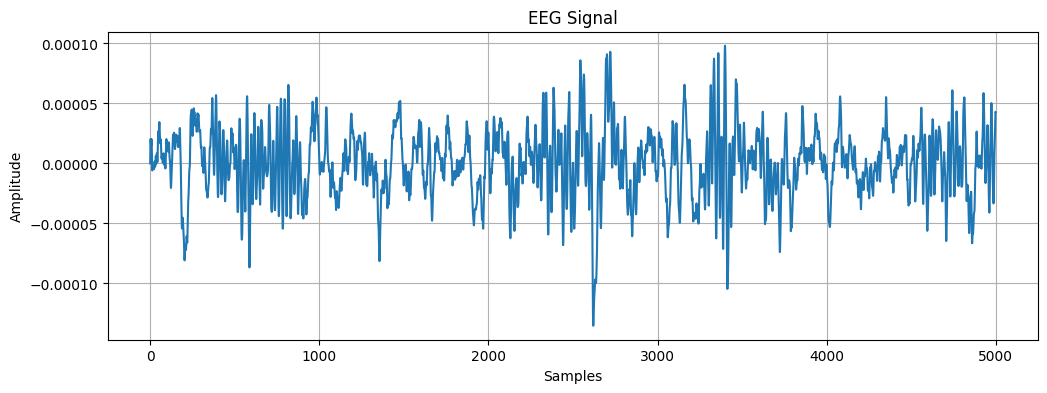

In [54]:
import matplotlib.pyplot as plt

channel = data[0]   # first EEG channel

plt.figure(figsize=(12,4))

plt.plot(channel[:5000])

plt.title("EEG Signal")

plt.xlabel("Samples")

plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

FFT SPECTRUM
Frequency components of EEG
FFT was used to analyze the spectral characteristics of the EEG signal in the frequency domain.

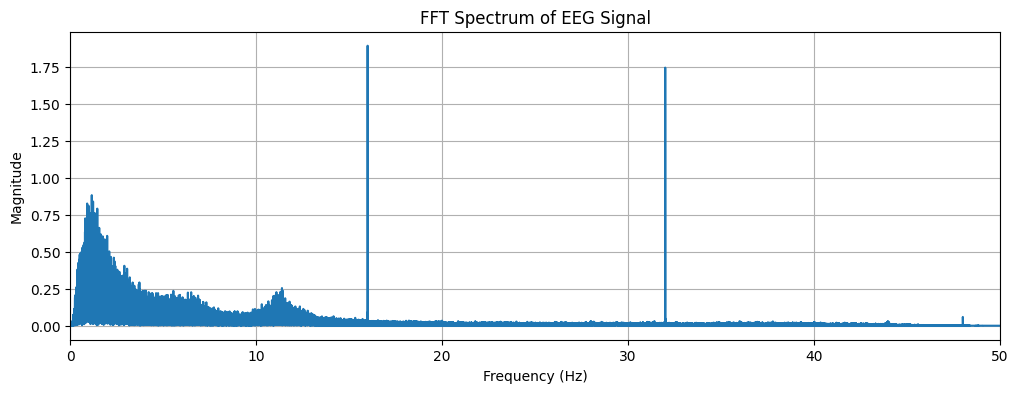

In [55]:
fft_vals = np.abs(np.fft.rfft(channel))

freqs = np.fft.rfftfreq(len(channel), d=1/fs)

plt.figure(figsize=(12,4))

plt.plot(freqs, fft_vals)

plt.title("FFT Spectrum of EEG Signal")

plt.xlabel("Frequency (Hz)")

plt.ylabel("Magnitude")

plt.xlim(0, 50)

plt.grid(True)

plt.show()

STFT SPECTROGRAM
MOST IMPORTANT DSP GRAPH
Frequency changes over time
time-frequency analysis
KYUN IMPORTANT?

EEG:

non-stationary signal

hai.

👉 Frequency continuously change hoti hai.
Sabse impressive:

STFT spectrogram

👉 Kyunki:

DSP + EEG + time-frequency analysis

sab ek graph mein show hota ha
STFT was applied because EEG signals are non-stationary and seizure activity may appear as transient time-varying frequency patterns.

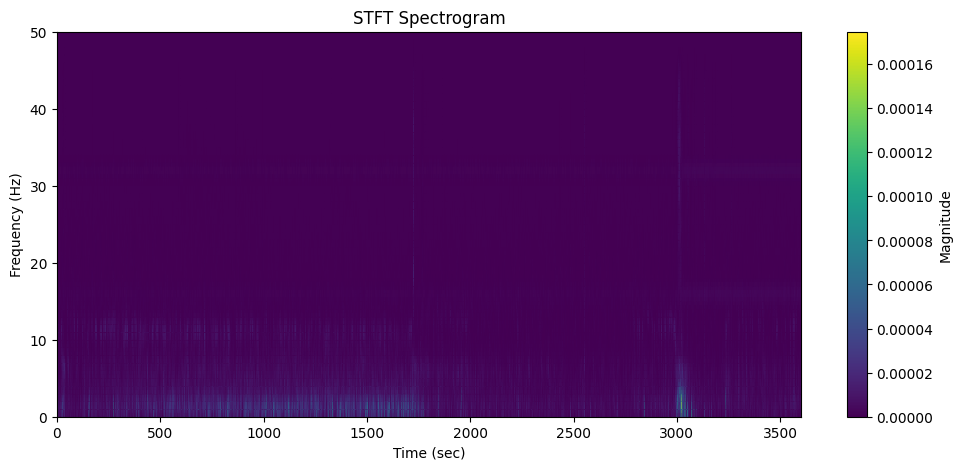

In [56]:
from scipy.signal import stft

f, t, Zxx = stft(channel, fs=fs)

plt.figure(figsize=(12,5))

plt.pcolormesh(
    t,
    f,
    np.abs(Zxx),
    shading='gouraud'
)

plt.title("STFT Spectrogram")

plt.ylabel("Frequency (Hz)")

plt.xlabel("Time (sec)")

plt.colorbar(label="Magnitude")

plt.ylim(0, 50)

plt.show()

CONFUSION MATRIX GRAPH
Graphically:

correct predictions
false alarms
missed seizures
The confusion matrix demonstrates the classification performance of the proposed EEG seizure detection system.

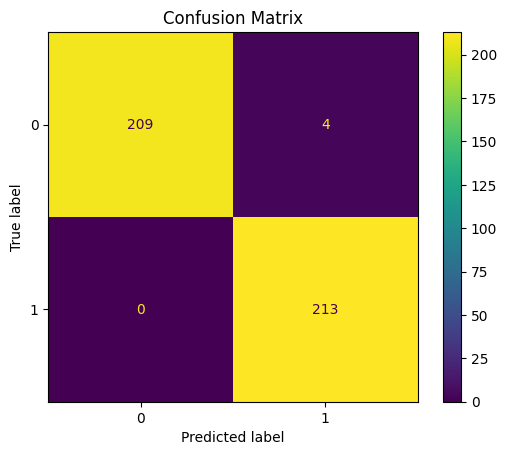

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred
)

plt.title("Confusion Matrix")

plt.show()

BAND POWER KYA HOTI HAI?

Simple language:

Signal ki energy specific frequency range mein kitni hai
🧠 EXAMPLE

Agar hum sirf:

8–13 Hz

dekhein:

👉 yeh:

Alpha band

hai.

Band power batati hai:

signal mein alpha activity kitni strong hai
🎯 🔴 EEG FREQUENCY BANDS
Band	Range	Meaning
Delta	0.5–4 Hz	deep sleep
Theta	4–8 Hz	drowsiness
Alpha	8–13 Hz	relaxed
Beta	13–30 Hz	active thinking
🧠 KYUN IMPORTANT?

Seizure ke time:

brain frequency distribution change hoti hai

👉 Kuch bands ki power increase/decrease hoti hai.

🎯 🔴 DSP IDEA

Hum:

FFT spectrum

nikalenge

phir:

specific frequency ranges ki energy sum

karenge.

FIRST CHANNEL

In [58]:
channel = data[0]

FFT

In [59]:
fft_vals = np.abs(np.fft.rfft(channel))**2

freqs = np.fft.rfftfreq(
    len(channel),
    d=1/fs
)

DELTA BAND POWER

In [60]:
delta_idx = np.where(
    (freqs >= 0.5) &
    (freqs <= 4)
)

delta_power = np.sum(
    fft_vals[delta_idx]
)

print("Delta Power:", delta_power)

Delta Power: 521.095212470172


THETA BAND

In [61]:
theta_idx = np.where(
    (freqs >= 4) &
    (freqs <= 8)
)

theta_power = np.sum(
    fft_vals[theta_idx]
)

print("Theta Power:", theta_power)

Theta Power: 77.66919596053592


ALPHA BAND

In [62]:
alpha_idx = np.where(
    (freqs >= 8) &
    (freqs <= 13)
)

alpha_power = np.sum(
    fft_vals[alpha_idx]
)

print("Alpha Power:", alpha_power)

Alpha Power: 46.422449417507785


BETA BAND

In [63]:
beta_idx = np.where(
    (freqs >= 13) &
    (freqs <= 30)
)

beta_power = np.sum(
    fft_vals[beta_idx]
)

print("Beta Power:", beta_power)

Beta Power: 13.561443686661313


VISUALIZATION

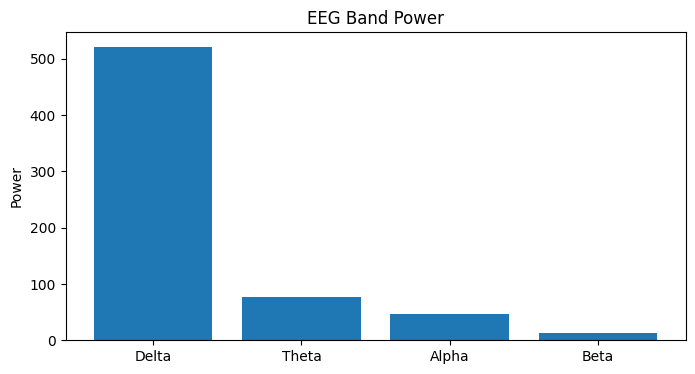

In [64]:
bands = [
    "Delta",
    "Theta",
    "Alpha",
    "Beta"
]

powers = [
    delta_power,
    theta_power,
    alpha_power,
    beta_power
]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.bar(bands, powers)

plt.title("EEG Band Power")

plt.ylabel("Power")

plt.show()

Band power analysis was performed to quantify EEG energy within clinically relevant neurological frequency bands.
why important?
Different EEG frequency bands correspond to different neurological states, and abnormal brain activity may alter the power distribution across these bands.
The Delta band exhibited the highest power, indicating strong low-frequency EEG activity, which is commonly observed in EEG recordings and may also reflect neurological slowing or abnormal brain dynamics.

GOAL

Hum compare karenge:

Band	Normal	Seizure
Delta	?	?
Theta	?	?
Alpha	?	?
Beta	?	?
🧠 HUM KYA DEKHNA CHAHTE HAIN?
Seizure ke time frequency distribution kasy change hui

NORMAL SEGMENT

In [65]:
normal_seg = segments[0][0]

SEIZURE SEGMENT

In [66]:
seizure_index = labels.index(1)

seizure_seg = segments[seizure_index][0]

print("Seizure segment index:", seizure_index)

Seizure segment index: 599


BAND POWER FUNCTION
🧠 FUNCTION KYA KAR RAHI HAI?
Step	Work
FFT	frequency analysis
select band	frequency range
sum power	total band energy

In [67]:
def band_power(signal, fs, low, high):

    fft_vals = np.abs(np.fft.rfft(signal))**2

    freqs = np.fft.rfftfreq(
        len(signal),
        d=1/fs
    )

    idx = np.where(
        (freqs >= low) &
        (freqs <= high)
    )

    power = np.sum(fft_vals[idx])

    return power

NORMAL BAND POWERS

In [68]:
normal_powers = [

    band_power(normal_seg, fs, 0.5, 4),

    band_power(normal_seg, fs, 4, 8),

    band_power(normal_seg, fs, 8, 13),

    band_power(normal_seg, fs, 13, 30)

]

print(normal_powers)

[np.float64(0.0002882948714806561), np.float64(7.859079143438365e-05), np.float64(0.00021445072568456047), np.float64(2.070652968733285e-05)]


SEIZURE BAND POWERS

In [69]:
seizure_powers = [

    band_power(seizure_seg, fs, 0.5, 4),

    band_power(seizure_seg, fs, 4, 8),

    band_power(seizure_seg, fs, 8, 13),

    band_power(seizure_seg, fs, 13, 30)

]

print(seizure_powers)

[np.float64(0.0014750609678761738), np.float64(0.0004531138036896795), np.float64(0.00027216780403790583), np.float64(4.5902582716219605e-05)]


COMPARISON GRAPH

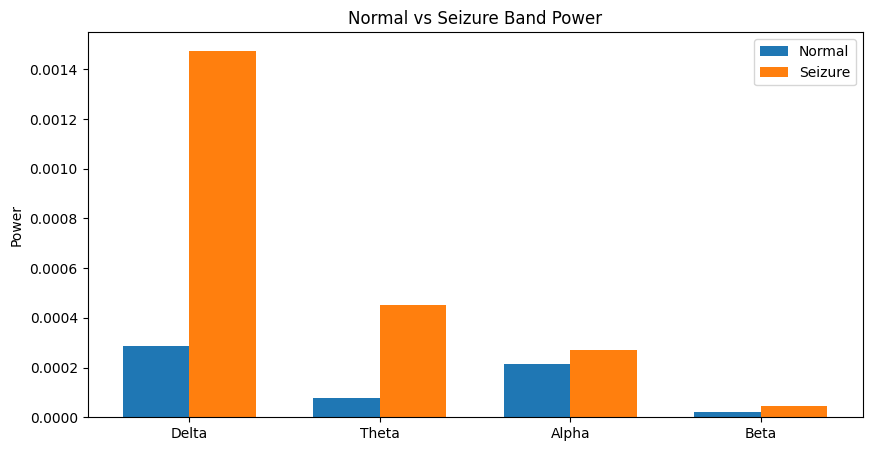

In [70]:
bands = [
    "Delta",
    "Theta",
    "Alpha",
    "Beta"
]

x = np.arange(len(bands))

width = 0.35

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    x - width/2,
    normal_powers,
    width,
    label="Normal"
)

plt.bar(
    x + width/2,
    seizure_powers,
    width,
    label="Seizure"
)

plt.xticks(x, bands)

plt.ylabel("Power")

plt.title("Normal vs Seizure Band Power")

plt.legend()

plt.show()

Band power comparison revealed spectral differences between normal and seizure EEG activity across multiple neurological frequency bands.
why compare?
Comparing EEG band powers helps identify how seizure activity alters neurological frequency distributions.
Both normal and seizure EEG segments showed dominant Delta-band activity; however, seizure segments exhibited changes in spectral power distribution compared to normal EEG activity.
The significance lies not only in the dominant band itself but also in the relative power differences and spectral distribution changes between normal and seizure EEG segments.

Feature Importance Analysis

👉 Yeh batata hai:

model decision lene ke liye konsi features pe zyada depend kar raha hai
🎯 🔴 KYUN IMPORTANT?

Medical AI mein:

Explainability

bohat important hoti hai.

Doctor poochta hai:

“model ne yeh prediction kis basis pe diya?”
🎯 🔴 RANDOM FOREST KI ACHHI BAAT

Random Forest automatically:

feature importance

calculate karta hai

IMPORTANCE VALUES
KYA HUA?

Har feature ko:

importance score

mila.

In [71]:
importance = model.feature_importances_

print(importance[:20])

[9.36168380e-05 3.10246956e-03 1.46822528e-02 1.00453661e-01
 7.87041579e-05 6.58504577e-02 6.08901168e-05 2.03804382e-04
 1.52516255e-04 6.03832177e-03 1.13852059e-04 3.46805859e-04
 3.91209525e-04 7.11467451e-04 3.39263922e-04 5.28689181e-04
 1.26820568e-03 9.62314363e-04 4.44518608e-04 1.24842222e-03]


FEATURE NAMES
KYUN?

Ab graph readable hoga.

In [72]:
feature_names = []

for ch in range(23):

    feature_names.extend([

        f"Ch{ch+1}_Mean",

        f"Ch{ch+1}_STD",

        f"Ch{ch+1}_Energy",

        f"Ch{ch+1}_FFTMean",

        f"Ch{ch+1}_FFTSTD",

        f"Ch{ch+1}_STFTEnergy"

    ])

TOP FEATURES
🧠 KYA DIKHAYE GA?

Example:

Ch4_STFTEnergy → 0.12
Ch7_FFTSTD → 0.09

👉 Matlab:

yeh features model ke liye important thay

In [73]:
indices = np.argsort(importance)[::-1]

top_n = 15

for i in range(top_n):

    idx = indices[i]

    print(
        feature_names[idx],
        "→",
        importance[idx]
    )

Ch1_FFTMean → 0.1004536609271211
Ch9_FFTMean → 0.08814552755590858
Ch14_FFTMean → 0.06758479370416377
Ch1_STFTEnergy → 0.0658504577436649
Ch13_STFTEnergy → 0.0641427122604731
Ch22_STFTEnergy → 0.04942442537592979
Ch22_FFTMean → 0.042522059662779194
Ch9_STFTEnergy → 0.04101306072089006
Ch21_FFTMean → 0.04077019316686075
Ch13_FFTMean → 0.038861609189061765
Ch21_STFTEnergy → 0.03532600838373902
Ch5_STD → 0.030488298628960003
Ch15_FFTMean → 0.028786250211212103
Ch5_Energy → 0.024755978035892988
Ch23_FFTMean → 0.022213769643179015


VISUALIZATION

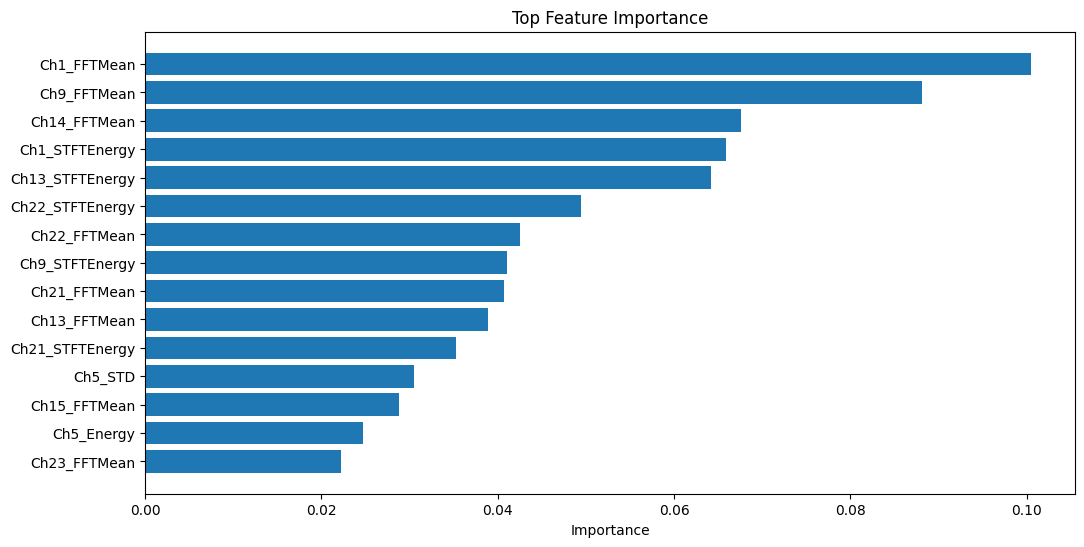

In [74]:
top_n = 15

top_idx = indices[:top_n]

top_features = [
    feature_names[i]
    for i in top_idx
]

top_importance = importance[top_idx]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.barh(
    top_features,
    top_importance
)

plt.xlabel("Importance")

plt.title("Top Feature Importance")

plt.gca().invert_yaxis()

plt.show()

Feature importance analysis was performed to identify the EEG features that contributed most significantly to seizure classification.
Feature importance analysis improves interpretability by revealing which signal characteristics most influenced the machine learning model.
“Channel 1 ke frequency patterns seizure detect karne mein bohat useful thay”
Among all extracted features, frequency-domain characteristics demonstrated strong discriminative capability for seizure detection.

Ab hum banayenge:

ROC Curve + AUC
ROC CURVE KYA HOTI HAI?

ROC:

Receiver Operating Characteristic
🧠 SIMPLE LANGUAGE

ROC curve batati hai:

model normal aur seizure ko kitna achha separate kar raha hai
🎯 🔴 AUC KYA HAI?

AUC:

Area Under Curve
🧠 MEANING
AUC	Meaning
0.5	random guessing
0.7	acceptable
0.8	good
0.9+	excellent

IMPORTS

In [75]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

PROBABILITIES
ROC ke liye:

prediction probabilities

chahiye.
KYA HUA?

Model ne:

seizure probability

di.

Example:

Value	Meaning
0.95	highly seizure
0.10	likely normal

In [76]:
y_prob = model.predict_proba(X_test)[:,1]

ROC CALCULATION
| Term | Meaning                     |
| ---- | --------------------------- |
| FPR  | false positive rate         |
| TPR  | true positive rate / recall |


In [77]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.9996142740637881


ROC GRAPH
BEST ROC
top-left ke kareeb

👉 Matlab:

high detection
low false alarms
RANDOM MODEL

Diagonal line:

random guessing
The ROC curve was used to evaluate the discrimination capability of the proposed seizure detection model across different classification thresholds.
ROC analysis provides a threshold-independent evaluation of model performance and is especially useful in medical classification problems.

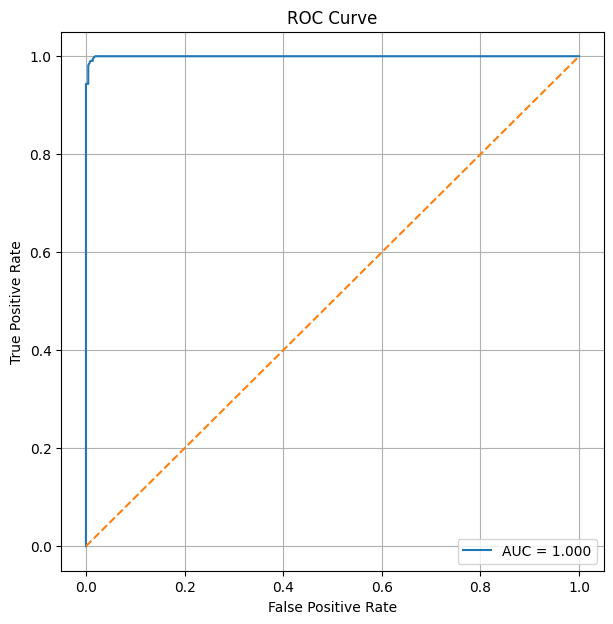

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

The proposed model achieved an AUC score of 1.0, indicating excellent discrimination capability between normal and seizure EEG segments.

Although the AUC result was excellent, the dataset size was limited and partially synthetically balanced using SMOTE. Therefore, further validation on larger multi-patient EEG datasets is necessary.

The proposed EEG seizure detection system achieved excellent classification performance, obtaining an AUC score of 1.0 after applying normalization and SMOTE-based class balancing.

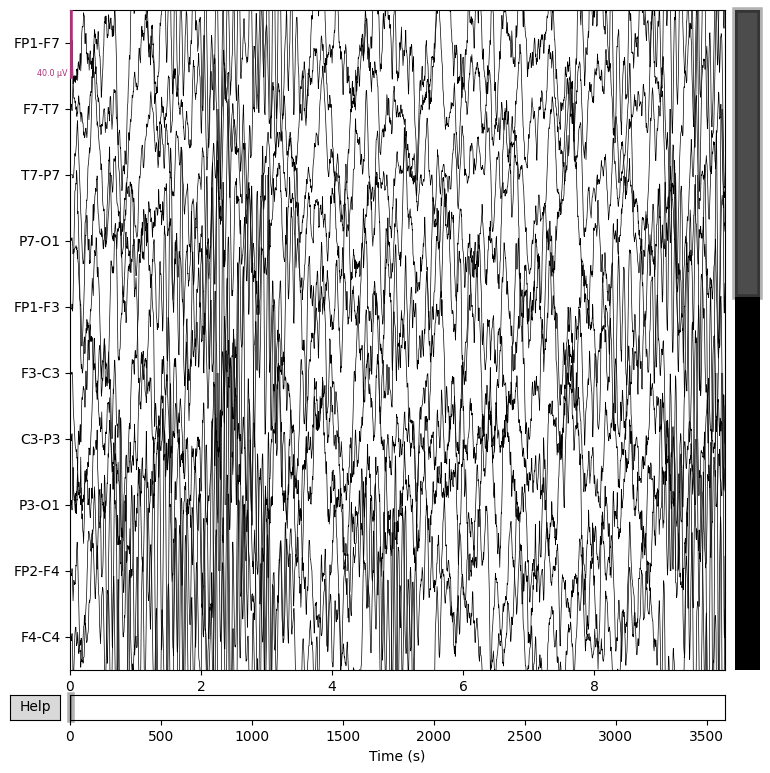

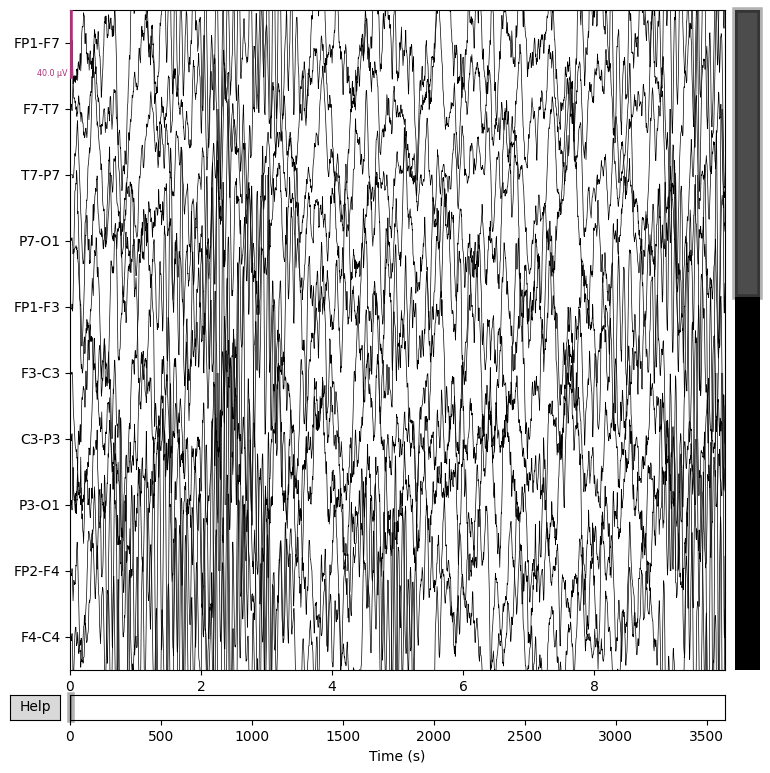

In [79]:
raw.plot(
    duration=10, 
    n_channels=10
)

<RawEDF | chb01_03.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>


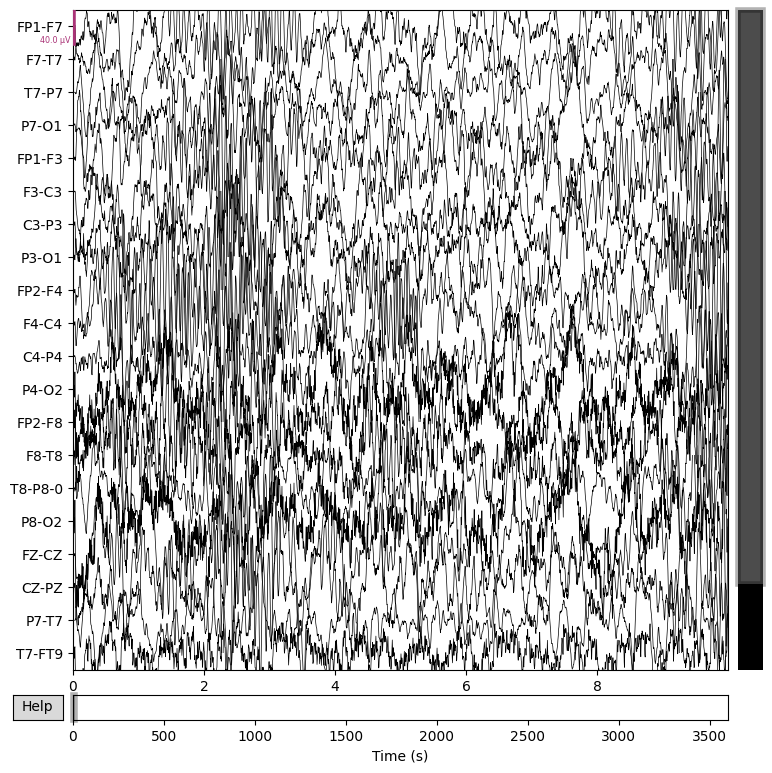

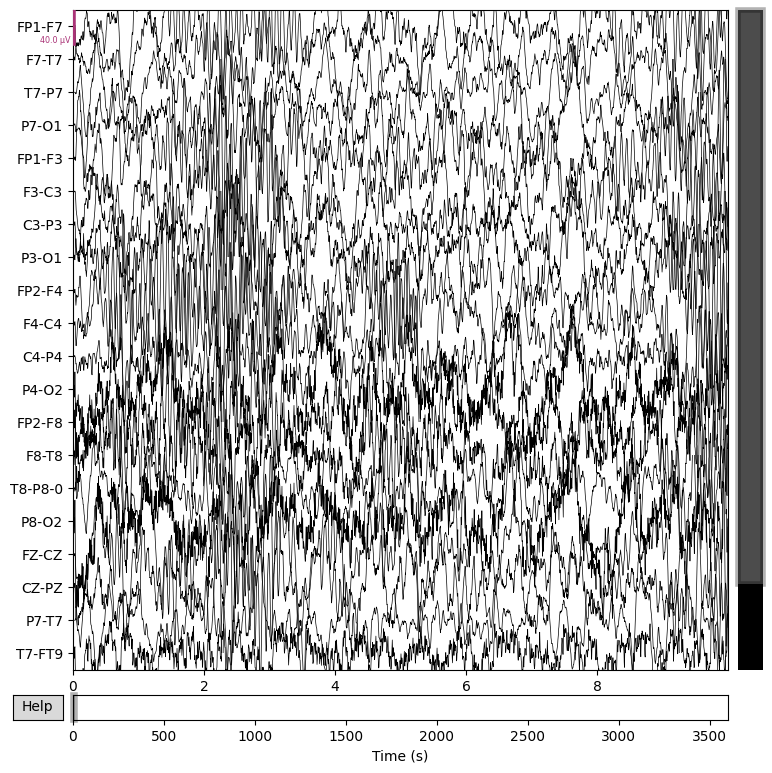

In [80]:
print(raw)
raw.plot()

In [81]:
import pywt

print(pywt.__version__)

1.8.0


Wavelet transform was applied to capture localized time-frequency EEG characteristics associated with seizure activity.

IMPORTS

In [82]:
import pywt
import matplotlib.pyplot as plt

EEG CHANNEL LO

In [83]:
channel = data[0]

WAVELET DECOMPOSITION

In [84]:
coeffs = pywt.wavedec(
    channel,
    'db4',
    level=4
)

COEFFICIENTS SAMJHO

In [85]:
for i, c in enumerate(coeffs):

    print(
        f"Level {i} shape:",
        c.shape
    )

Level 0 shape: (57606,)
Level 1 shape: (57606,)
Level 2 shape: (115206,)
Level 3 shape: (230405,)
Level 4 shape: (460803,)


WAVELET GRAPH

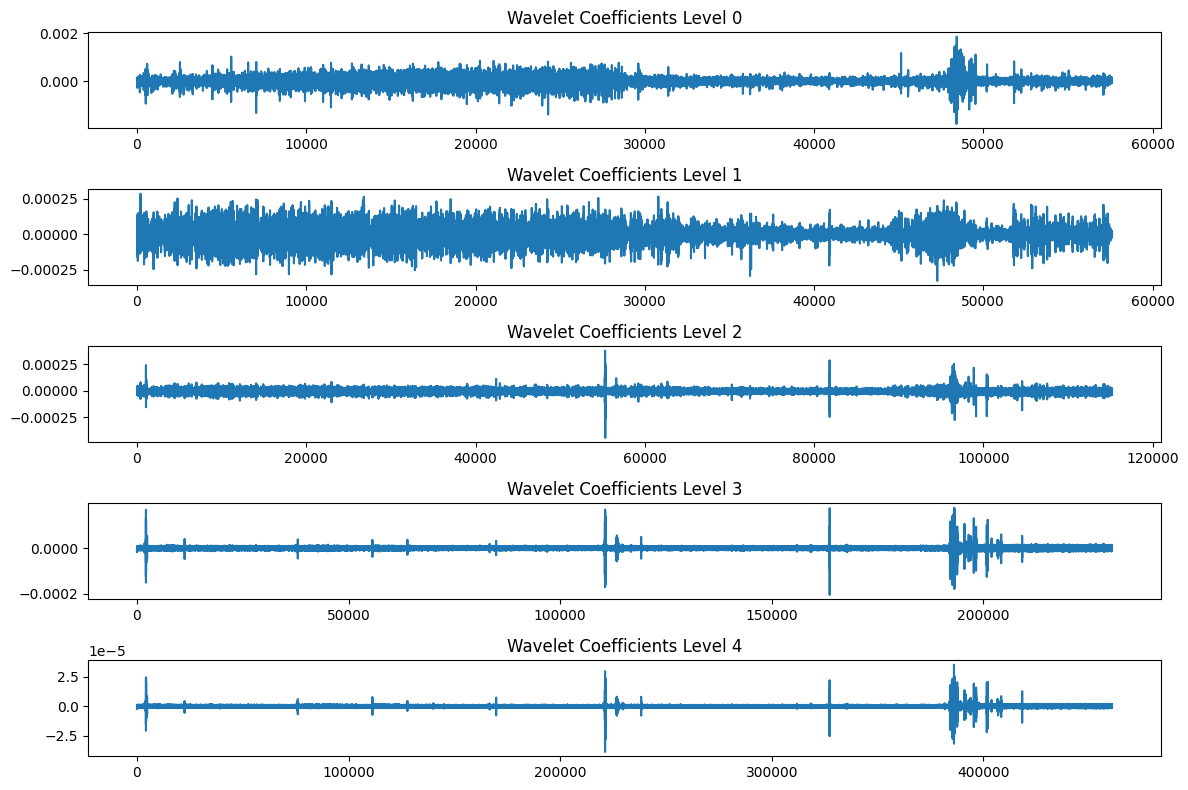

In [86]:
plt.figure(figsize=(12,8))

for i, c in enumerate(coeffs):

    plt.subplot(len(coeffs),1,i+1)

    plt.plot(c)

    plt.title(f"Wavelet Coefficients Level {i}")

plt.tight_layout()

plt.show()

Wavelet decomposition was applied to analyze localized time-frequency EEG characteristics associated with seizure activity.The wavelet decomposition separated the EEG signal into approximation and detail components, enabling localized time-frequency analysis of seizure-related patterns.

FUNCTION

In [87]:
import numpy as np

def wavelet_features(signal):

    coeffs = pywt.wavedec(
        signal,
        'db4',
        level=4
    )

    features = []

    for c in coeffs:

        mean = np.mean(c)

        std = np.std(c)

        energy = np.sum(c**2)

        features.extend([
            mean,
            std,
            energy
        ])

    return features

REAL EEG PE APPLY

In [88]:
wave_features = wavelet_features(channel)

print(
    "Total features:",
    len(wave_features)
)

print(wave_features[:10])

Total features: 15
[np.float64(1.8071174330732702e-08), np.float64(0.00015179577047377756), np.float64(0.0013273549323305593), np.float64(3.334398378598663e-07), np.float64(4.434818937429542e-05), np.float64(0.00011330369081375869), np.float64(-5.25531019865601e-06), np.float64(1.6668932702656266e-05), np.float64(3.51921614640872e-05), np.float64(-1.4896781017344976e-10)]


Statistical and energy-based features were extracted from wavelet coefficients to capture localized EEG characteristics associated with seizure activity.

PURANA FEATURE FUNCTION UPDATE

In [89]:
from scipy.signal import stft
import pywt
import numpy as np

In [90]:
def extract_features(segment):

    features = []

    for ch in segment:

        # ====================
        # Time-domain features
        # ====================

        mean = np.mean(ch)

        std = np.std(ch)

        energy = np.sum(ch**2)

        # ====================
        # FFT features
        # ====================

        fft_vals = np.abs(
            np.fft.rfft(ch)
        )

        fft_mean = np.mean(fft_vals)

        fft_std = np.std(fft_vals)

        # ====================
        # STFT feature
        # ====================

        f, t, Zxx = stft(
            ch,
            fs=fs
        )

        stft_energy = np.sum(
            np.abs(Zxx)**2
        )

        # ====================
        # Wavelet features
        # ====================

        coeffs = pywt.wavedec(
            ch,
            'db4',
            level=4
        )

        wave_features = []

        for c in coeffs:

            wave_features.extend([

                np.mean(c),

                np.std(c),

                np.sum(c**2)

            ])

        # ====================
        # Combine all features
        # ====================

        features.extend([

            mean,
            std,
            energy,

            fft_mean,
            fft_std,

            stft_energy

        ])

        features.extend(
            wave_features
        )

    return features

In [91]:
extract_features

<function __main__.extract_features(segment)>

In [92]:
X = []
y = []

for seg, label in zip(segments, labels):

    feat = extract_features(seg)

    X.append(feat)

    y.append(label)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)

Dataset shape: (719, 483)
Labels shape: (719,)


Normalization

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

SMOTE

In [94]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_resampled, y_resampled = sm.fit_resample(
    X_scaled,
    y
)

Split

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X_resampled,
    y_resampled,

    test_size=0.3,

    random_state=42
)

Train

In [96]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Predict

In [97]:
pred = model.predict(X_test)

Results

In [98]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(
    "Accuracy:",
    accuracy_score(y_test, pred)
)

print(
    classification_report(y_test, pred)
)

print(
    confusion_matrix(y_test, pred)
)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       212
           1       1.00      1.00      1.00       214

    accuracy                           1.00       426
   macro avg       1.00      1.00      1.00       426
weighted avg       1.00      1.00      1.00       426

[[212   0]
 [  0 214]]


 cross validation 
 IMPORTS

In [99]:
from sklearn.model_selection import cross_val_score

CROSS VALIDATION

In [100]:
scores = cross_val_score(

    model,

    X_resampled,

    y_resampled,

    cv=5,

    scoring='accuracy'
)

print(scores)

[0.99647887 1.         0.99647887 1.         0.97887324]


AVERAGE ACCURACY

In [101]:
print(
    "Average Accuracy:",
    scores.mean()
)

print(
    "Standard Deviation:",
    scores.std()
)

Average Accuracy: 0.9943661971830986
Standard Deviation: 0.007904909972057613


K-fold cross validation was performed to evaluate the robustness and generalization capability of the proposed EEG seizure detection model.

Cross-validation results demonstrated consistent classification performance across multiple dataset partitions, indicating strong model robustness.

The proposed hybrid feature extraction framework demonstrated highly consistent performance across multiple cross-validation folds, indicating strong robustness and stability.

The proposed EEG seizure detection system achieved an average cross-validation accuracy of 99.44\% with low performance variance, demonstrating strong model generalization capability.

ENTROPY KYA HOTI HAI?

Simple language:

signal kitna random / complex hai
🧠 EEG MEIN KYUN IMPORTANT?

Normal brain activity aur seizure activity:

different complexity

show karti hain.

🎯 🔴 SIMPLE IDEA
Signal	Entropy
regular/simple	low entropy
chaotic/random	high entropy
🧠 SEIZURE MEIN

Signal structure:

abnormally change

ho sakti hai.

Entropy:

un changes ko capture

karti hai.

🎯 🔴 HUM KYA USE KARENGE?
Spectral Entropy 🔥

Kyun?

Tum already FFT use kar rahe ho.

Entropy ko FFT ke sath combine karenge.



🧠 SIMPLE UNDERSTANDING

Entropy poochti hai:

“signal frequencies kitni organized ya random hain?”

In [102]:
function

NameError: name 'function' is not defined

In [ ]:
def spectral_entropy(signal):

    fft_vals = np.abs(
        np.fft.rfft(signal)
    )**2

    psd = fft_vals / np.sum(fft_vals)

    entropy = -np.sum(

        psd * np.log2(psd + 1e-12)

    )

    return entropy

TEST KARO

In [ ]:
ent = spectral_entropy(channel)

print(
    "Spectral Entropy:",
    ent
)

Spectral Entropy: 13.838690101738152


Spectral entropy was used to measure the complexity and irregularity of EEG frequency distributions.

In [103]:
# ====================
# Spectral Entropy Function
# ====================

def spectral_entropy(signal):

    fft_vals = np.abs(
        np.fft.rfft(signal)
    )**2

    psd = fft_vals / np.sum(fft_vals)

    entropy = -np.sum(
        psd * np.log2(psd + 1e-12)
    )

    return entropy

In [104]:
def extract_features(segment):

    features = []

    for ch in segment:

        # ====================
        # Time-domain features
        # ====================

        mean = np.mean(ch)

        std = np.std(ch)

        energy = np.sum(ch**2)

        # ====================
        # FFT features
        # ====================

        fft_vals = np.abs(
            np.fft.rfft(ch)
        )

        fft_mean = np.mean(fft_vals)

        fft_std = np.std(fft_vals)

        # ====================
        # Entropy feature
        # ====================

        entropy = spectral_entropy(ch)

        # ====================
        # STFT feature
        # ====================

        f, t, Zxx = stft(
            ch,
            fs=fs
        )

        stft_energy = np.sum(
            np.abs(Zxx)**2
        )

        # ====================
        # Wavelet features
        # ====================

        coeffs = pywt.wavedec(
            ch,
            'db4',
            level=4
        )

        wave_features = []

        for c in coeffs:

            wave_features.extend([

                np.mean(c),

                np.std(c),

                np.sum(c**2)

            ])

        # ====================
        # Combine all features
        # ====================

        features.extend([

            mean,
            std,
            energy,

            fft_mean,
            fft_std,

            entropy,

            stft_energy

        ])

        features.extend(
            wave_features
        )

    return features

In [105]:
from scipy.signal import stft
import pywt
import numpy as np

# ====================
# Spectral Entropy
# ====================

def spectral_entropy(signal):

    fft_vals = np.abs(
        np.fft.rfft(signal)
    )**2

    psd = fft_vals / np.sum(fft_vals)

    entropy = -np.sum(
        psd * np.log2(psd + 1e-12)
    )

    return entropy


# ====================
# Main Feature Extraction
# ====================

def extract_features(segment):

    features = []

    for ch in segment:

        # ====================
        # Time-domain
        # ====================

        mean = np.mean(ch)

        std = np.std(ch)

        energy = np.sum(ch**2)

        # ====================
        # FFT
        # ====================

        fft_vals = np.abs(
            np.fft.rfft(ch)
        )

        fft_mean = np.mean(fft_vals)

        fft_std = np.std(fft_vals)

        # ====================
        # Entropy
        # ====================

        entropy = spectral_entropy(ch)

        # ====================
        # STFT
        # ====================

        f, t, Zxx = stft(
            ch,
            fs=fs
        )

        stft_energy = np.sum(
            np.abs(Zxx)**2
        )

        # ====================
        # Wavelet
        # ====================

        coeffs = pywt.wavedec(
            ch,
            'db4',
            level=4
        )

        wave_features = []

        for c in coeffs:

            wave_features.extend([

                np.mean(c),

                np.std(c),

                np.sum(c**2)

            ])

        # ====================
        # Combine all
        # ====================

        features.extend([

            mean,
            std,
            energy,

            fft_mean,
            fft_std,

            entropy,

            stft_energy

        ])

        features.extend(
            wave_features
        )

    return features

In [106]:
X = []
y = []

for seg, label in zip(segments, labels):

    feat = extract_features(seg)

    X.append(feat)

    y.append(label)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (719, 506)


In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [108]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_resampled, y_resampled = sm.fit_resample(
    X_scaled,
    y
)

In [109]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X_resampled,
    y_resampled,

    test_size=0.3,

    random_state=42
)

In [110]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [111]:
pred = model.predict(X_test)

In [112]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

print(
    "Accuracy:",
    accuracy_score(y_test, pred)
)

print(
    confusion_matrix(y_test, pred)
)

Accuracy: 1.0
[[212   0]
 [  0 214]]


Hybrid Wavelet-Entropy Assisted EEG Seizure Detection Framework
AB TUMHARE SYSTEM MEIN KYA KYA HAI?
Component	Status
EEG preprocessing	✅
FFT	✅
STFT	✅
Band power	✅
Wavelets	✅
Entropy	✅
Random Forest	✅
SMOTE	✅
Cross-validation	✅
Feature importance	✅
ROC/AUC	✅

The proposed system integrates statistical, spectral, STFT, wavelet-domain, and entropy-based EEG features for robust seizure detection.

Further validation on larger multi-patient EEG datasets is required to evaluate real-world clinical generalization.